In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
plt.rcParams['figure.figsize'] = [15, 6]
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import MinMaxScaler

In [6]:
dt = pd.read_csv("heart.csv")
data = dt.copy()

In [8]:
data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [10]:
data.dtypes

age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object

In [12]:
data.isnull().sum(axis = 0)

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [14]:
data.target.value_counts()

target
1    526
0    499
Name: count, dtype: int64

In [16]:
for col in data.columns:
    print(col," : ", data[col].unique().size)

age  :  41
sex  :  2
cp  :  4
trestbps  :  49
chol  :  152
fbs  :  2
restecg  :  3
thalach  :  91
exang  :  2
oldpeak  :  40
slope  :  3
ca  :  5
thal  :  4
target  :  2


<Axes: >

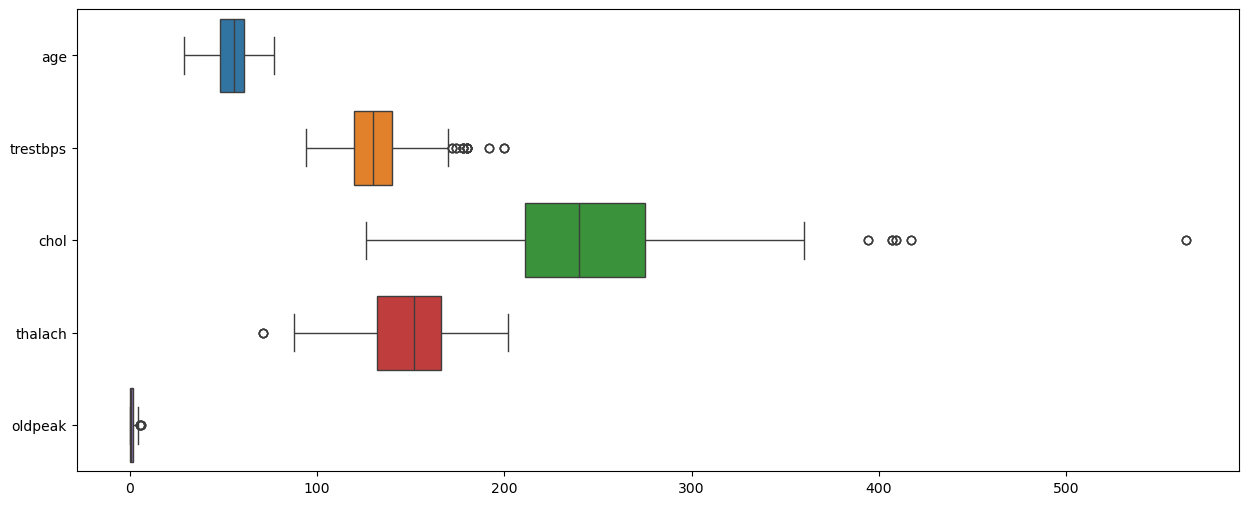

In [18]:
df = data
for col in data.columns:
    if df[col].unique().size < 6:                # 5 is the maximum for 'value_couts' categorical features 
        df = df.drop(columns = [col])
sns.boxplot(data = df, orient = 'h')

In [20]:
positive =data[data['target'] == 1]
negative =data[data['target'] == 0]

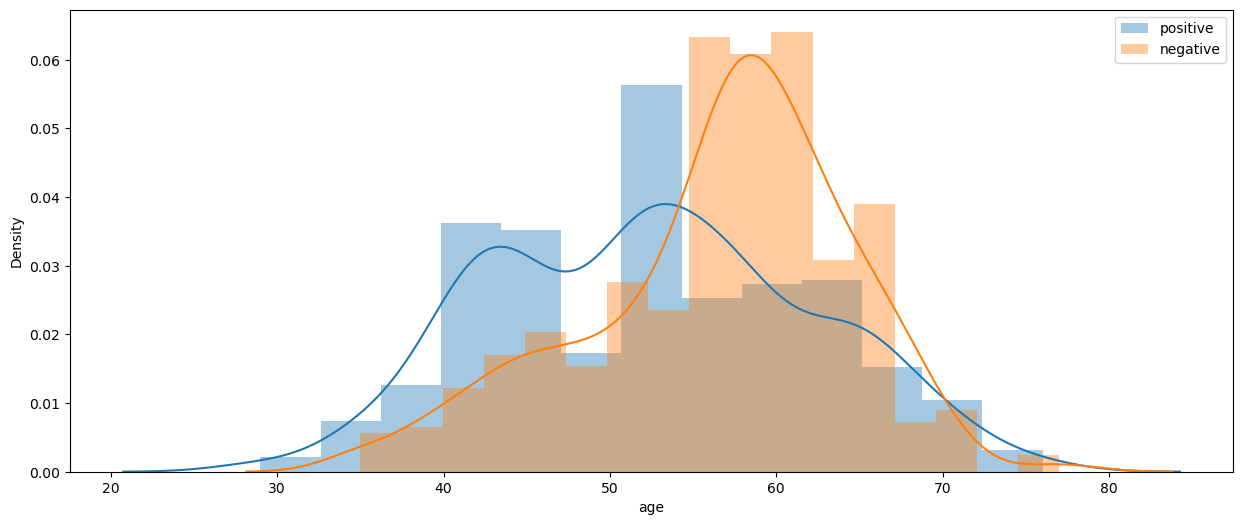

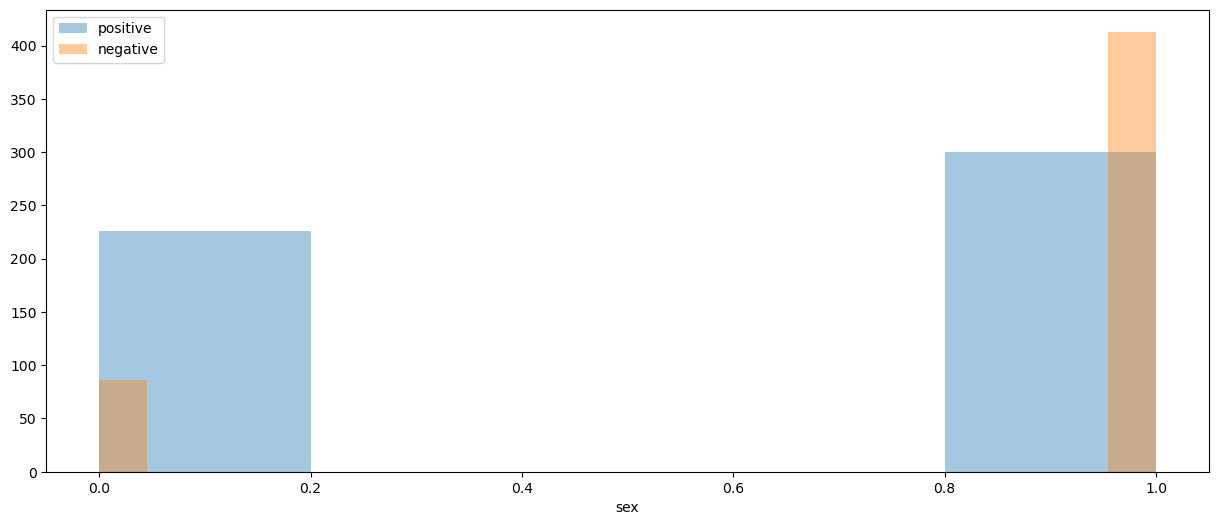

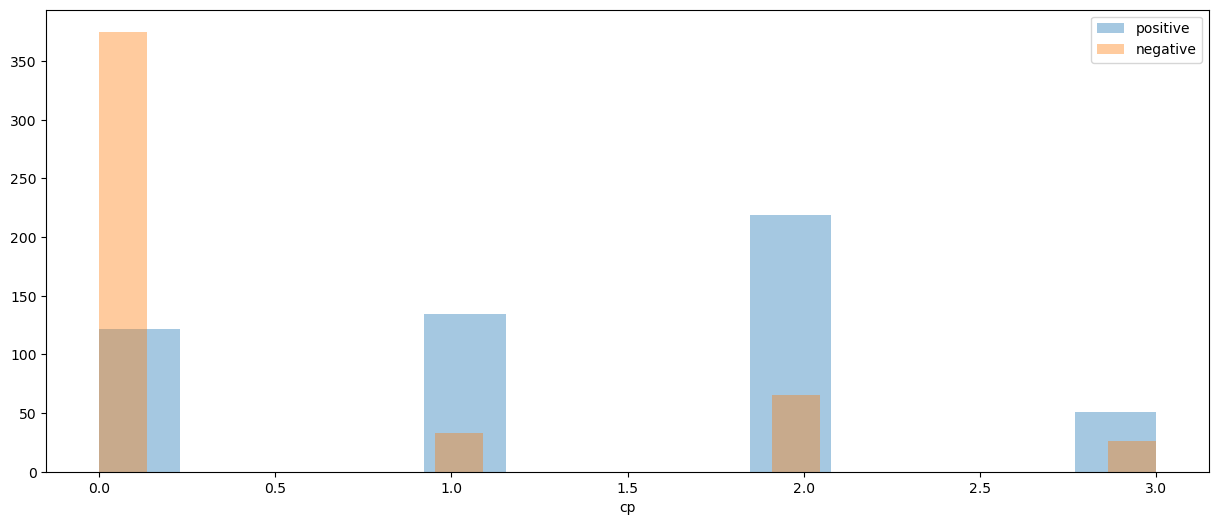

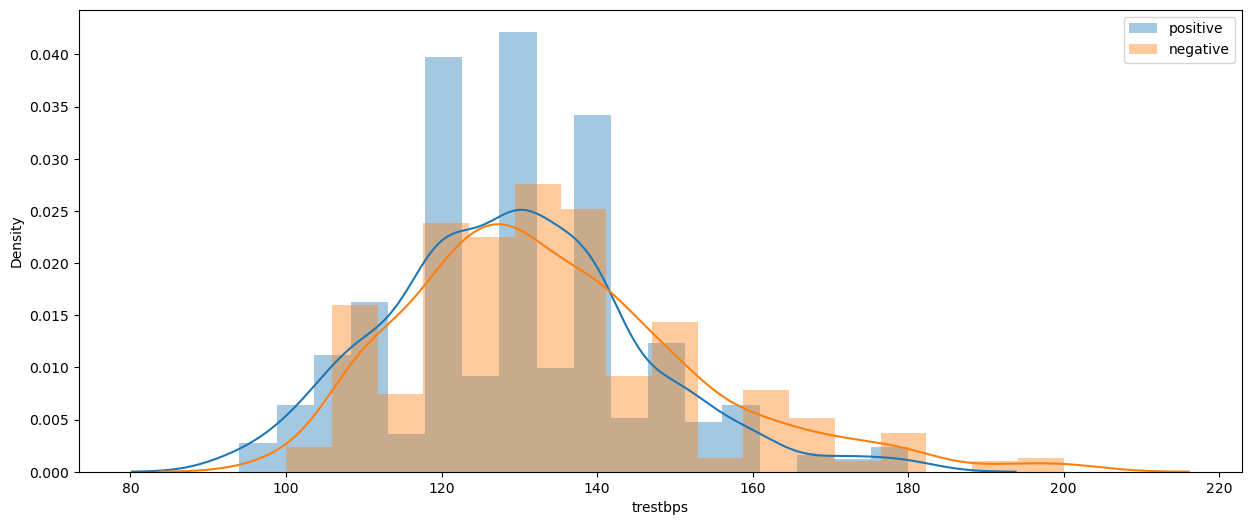

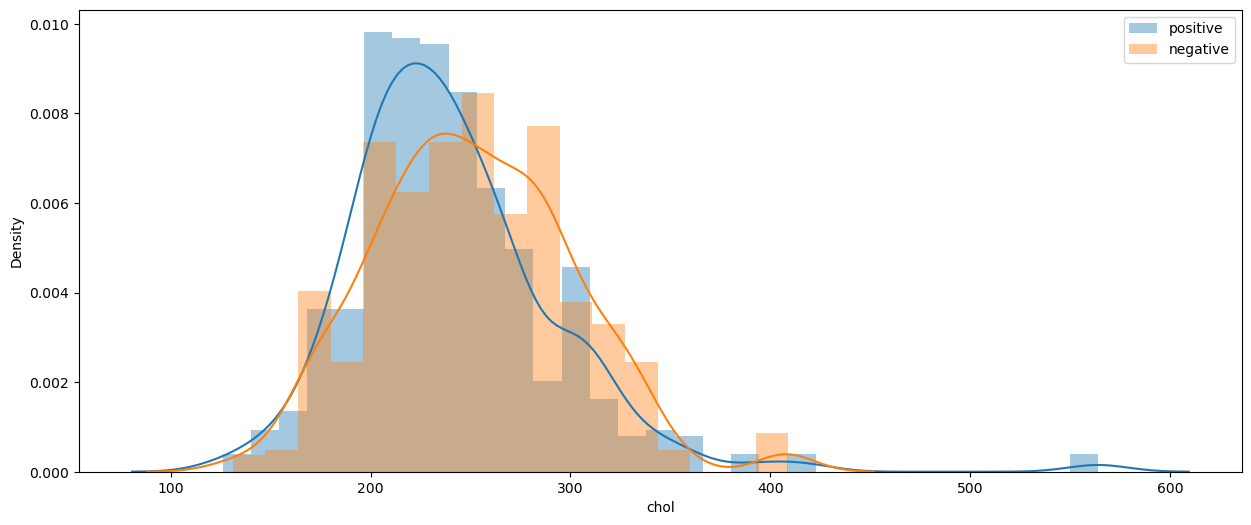

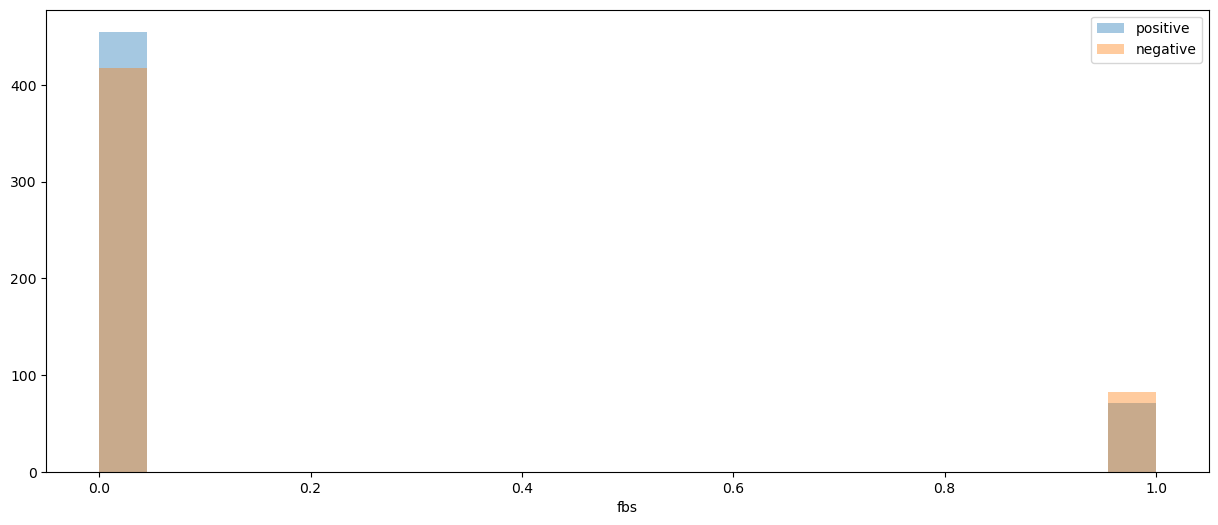

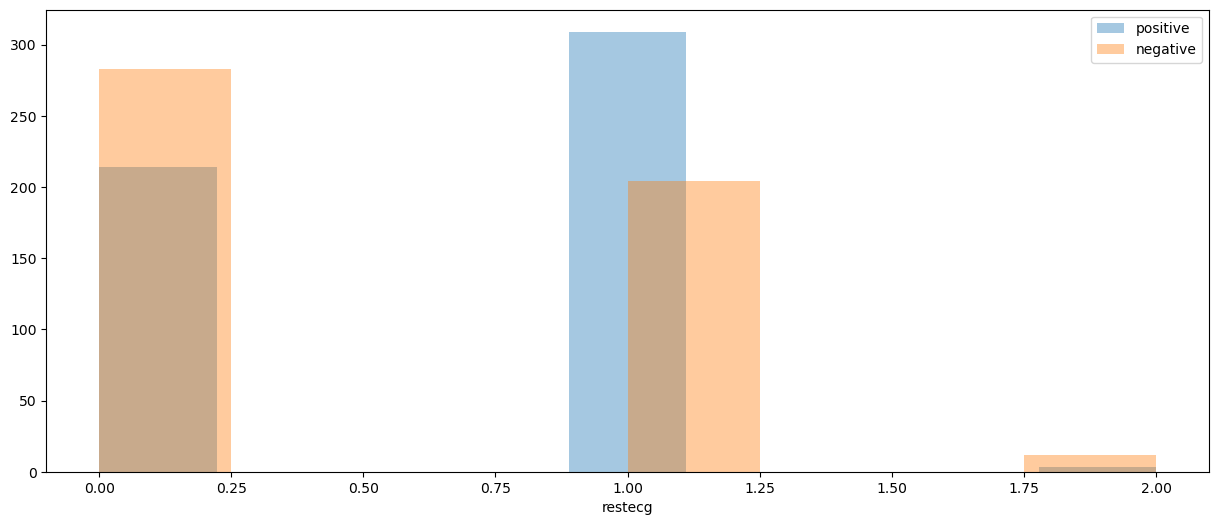

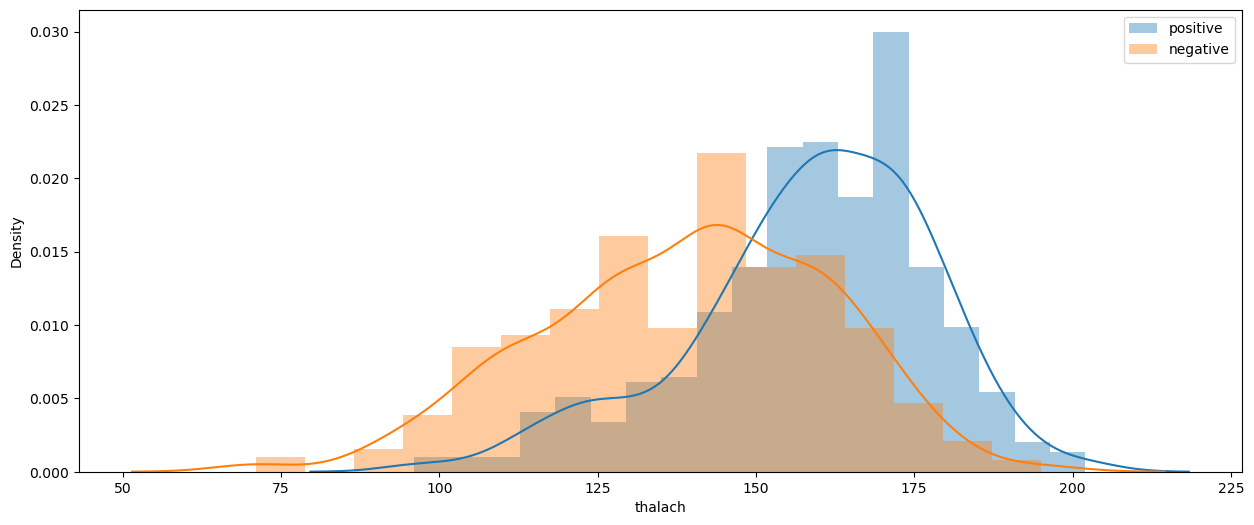

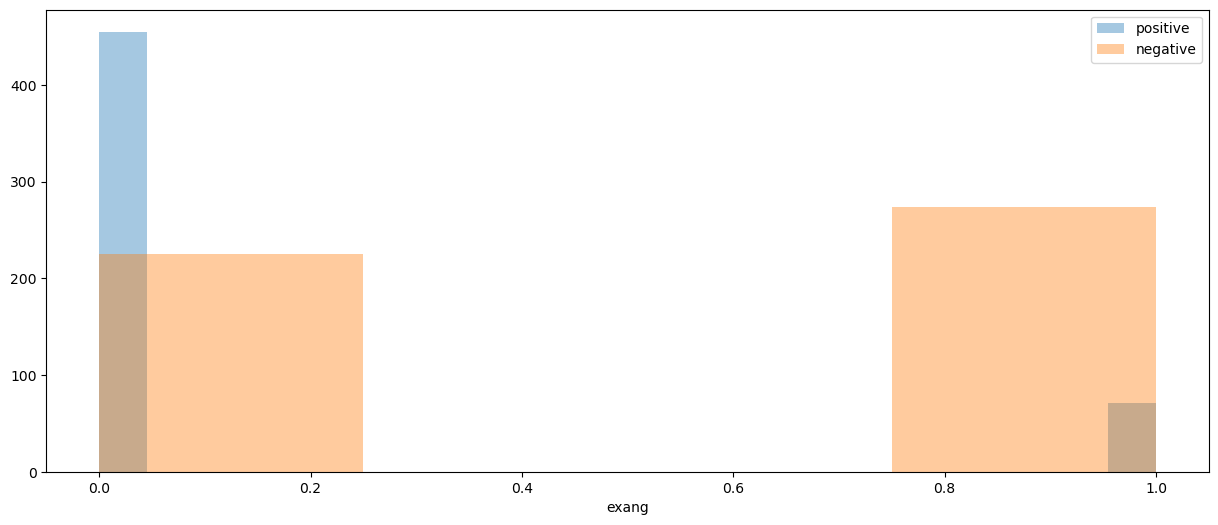

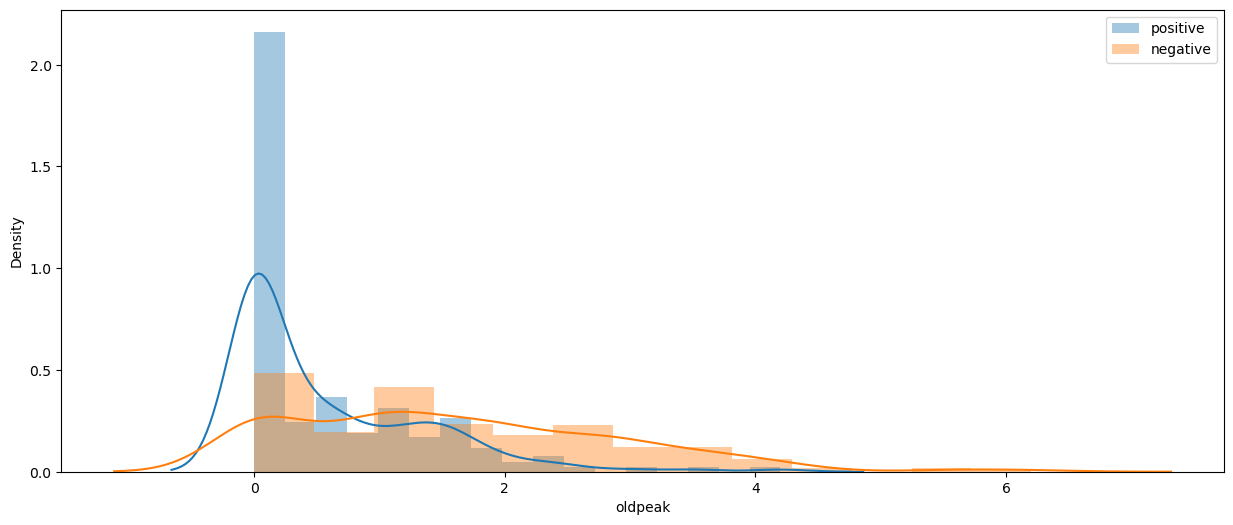

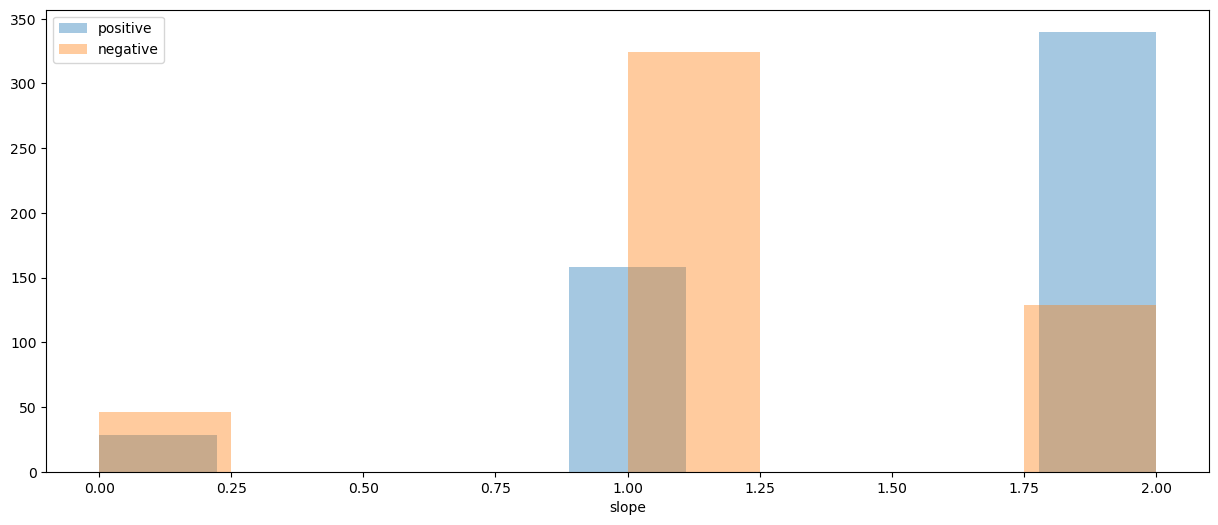

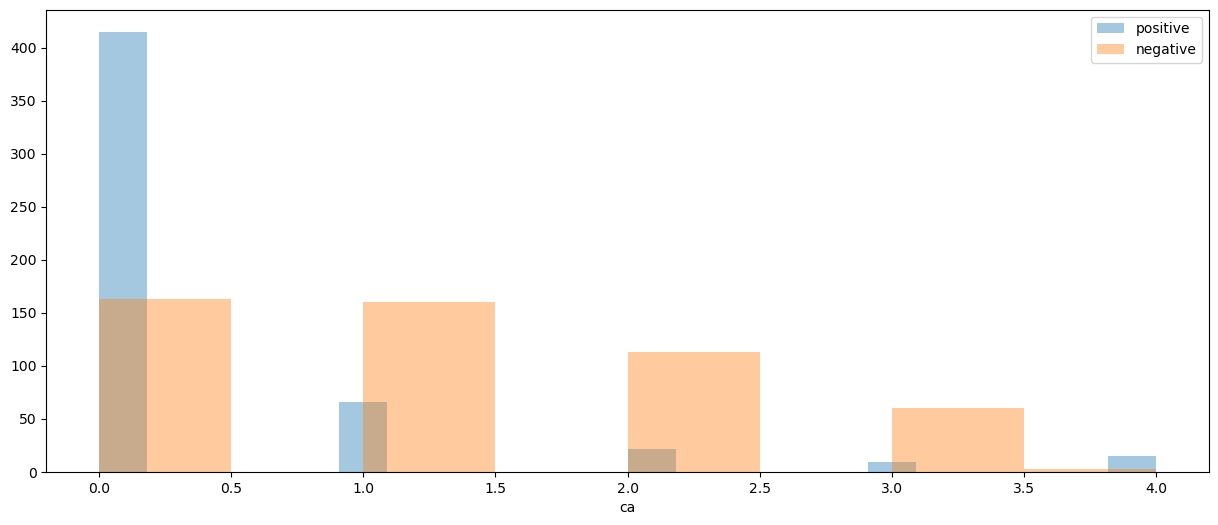

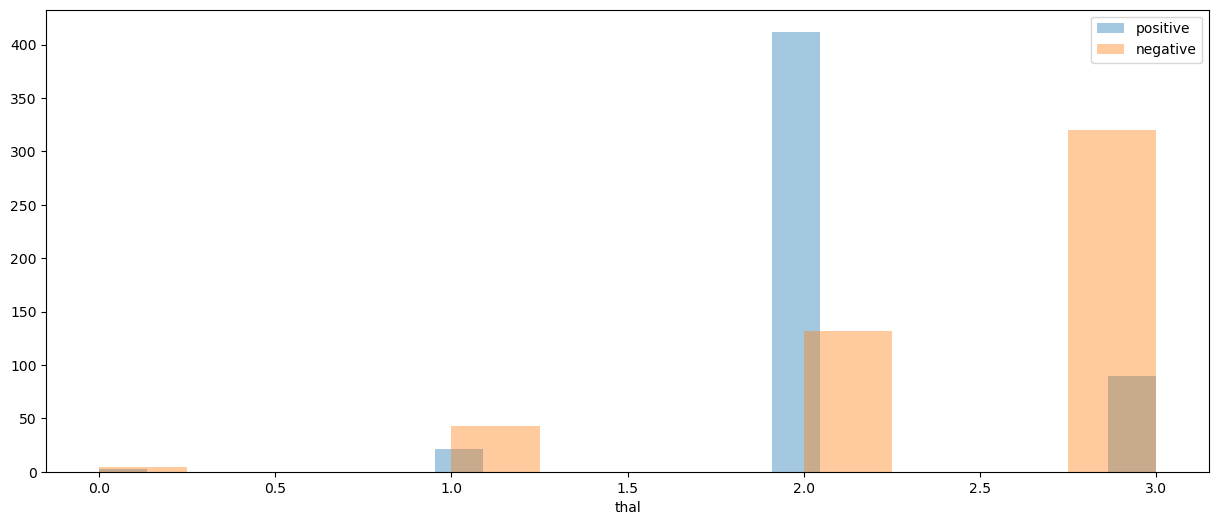

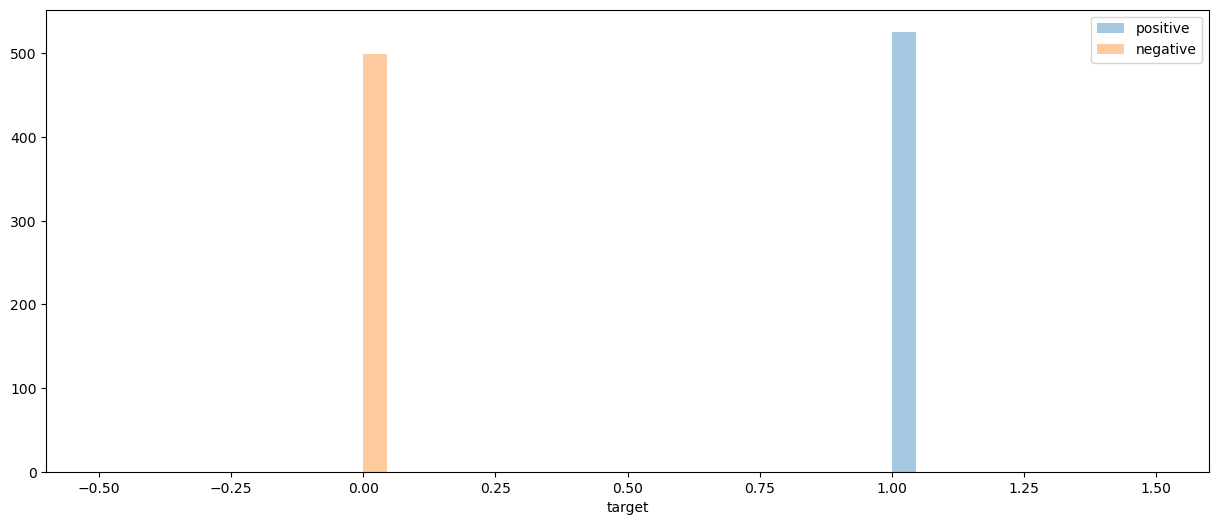

In [22]:
def set_kde(col):
    if data[col].unique().size < 7:
        return False
    else : return True
    
    
for col in data.columns :
    plt.figure()
    sns.distplot(positive[col], label = 'positive', kde = set_kde(col))
    sns.distplot(negative[col], label = 'negative', kde = set_kde(col))
    plt.legend()

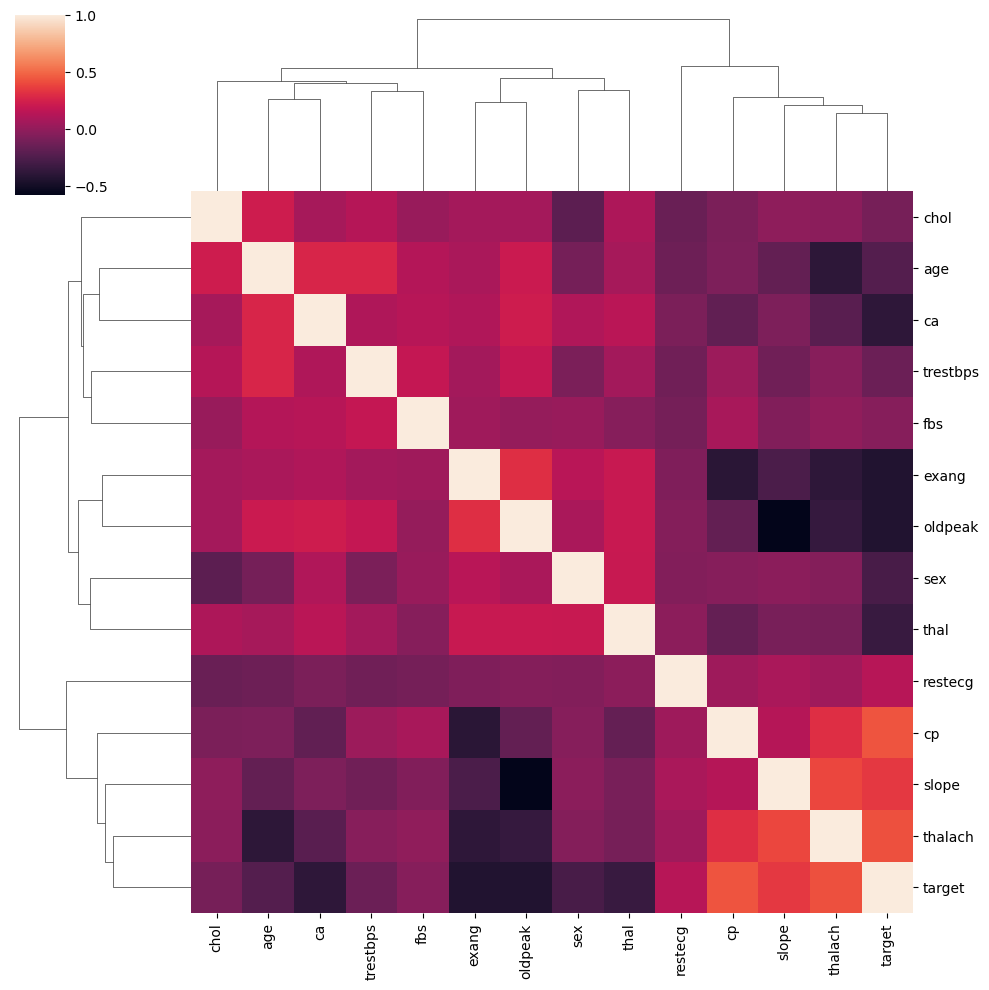

In [24]:
sns.clustermap(data.corr())

In [26]:
a = pd.get_dummies(data['cp'], prefix = "cp")
b = pd.get_dummies(data['thal'], prefix = "thal")
c = pd.get_dummies(data['slope'], prefix = "slope")

frames = [data, a, b, c]
data = pd.concat(frames, axis = 1)

data = data.drop(columns = ['cp', 'thal', 'slope'])

In [28]:
data.head()


,age,sex,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,ca,...,cp_1,cp_2,cp_3,thal_0,thal_1,thal_2,thal_3,slope_0,slope_1,slope_2
0,52,1,125,212,0,1,168,0,1.0,2,...,False,False,False,False,False,False,True,False,False,True
1,53,1,140,203,1,0,155,1,3.1,0,...,False,False,False,False,False,False,True,True,False,False
2,70,1,145,174,0,1,125,1,2.6,0,...,False,False,False,False,False,False,True,True,False,False
3,61,1,148,203,0,1,161,0,0.0,1,...,False,False,False,False,False,False,True,False,False,True
4,62,0,138,294,1,1,106,0,1.9,3,...,False,False,False,False,False,True,False,False,True,False


In [30]:
y = data['target']
X = data.drop(columns = ['target'])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state = 0)

In [36]:
def prepare_data(dt):
    y = dt['target']
    X = dt.drop(columns = ['target'])
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state = 0)

    scaler = MinMaxScaler()
    scaler.fit(X_train)
    X_train_scaled = scaler.transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    return X_train_scaled, X_test_scaled

X_train_scaled, X_test_scaled = prepare_data(dt)

In [38]:
from sklearn.ensemble import RandomForestClassifier
RF = RandomForestClassifier(random_state = 0)

In [44]:
from sklearn.neighbors import KNeighborsClassifier
KNN = KNeighborsClassifier()

grid_params = {
    'n_neighbors' : range(2,20),
    'weights' : ['uniform', 'distance'],
    'metric' : ['euclidean', 'manhattan']
}

GKNN = GridSearchCV(
    KNN,
    grid_params,
    cv = 4
)

In [46]:
from sklearn.svm import SVC
SVM = SVC(random_state = 1)

In [48]:
from sklearn.naive_bayes import GaussianNB
NB = GaussianNB()

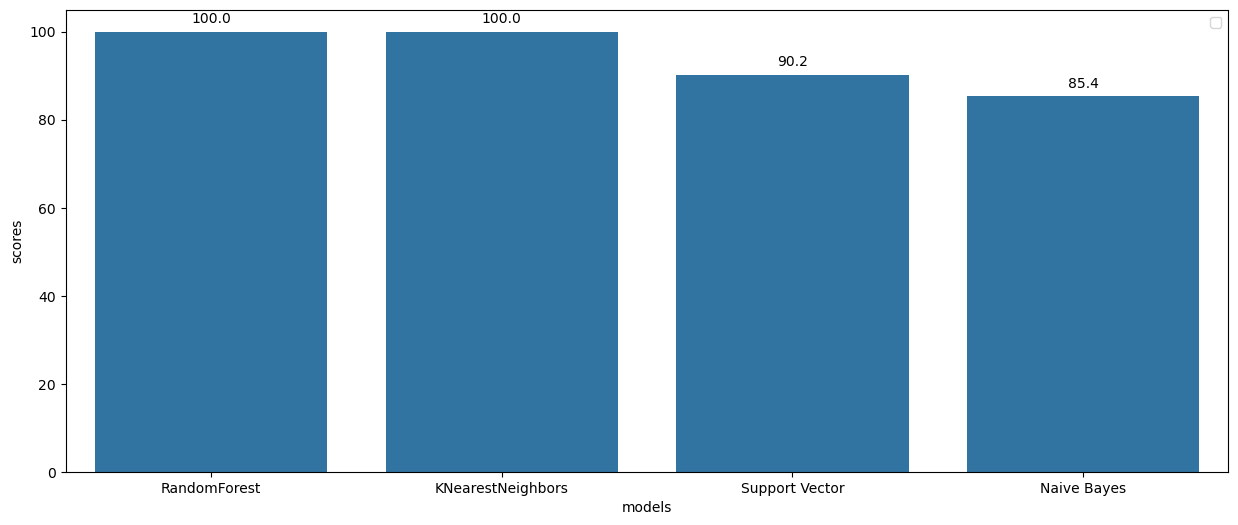

[100.0, 100.0, 90.2439024390244, 85.36585365853658]

In [52]:
def evaluation(X_train_scaled, X_test_scaled, msg = ''):
    models = {'RandomForest' : RF,
          'KNearestNeighbors': GKNN,
          'Support Vector' : SVM,
          'Naive Bayes' : NB}

    dfmd = pd.DataFrame(list(models.items()),columns = ['models','params'])
    labels = models.keys()

    scores = []
    for mdl in models.values(): 
        mdl.fit(X_train_scaled, y_train)
        scores.append(100 * mdl.score(X_test_scaled, y_test))
    dfmd['scores'] = scores
    #print(np.mean(scores))
    #if msg != '': print(msg)
    splot = plt.figure()
    splot = sns.barplot(data = dfmd, y = 'scores', x = 'models')
    for p in splot.patches:
        splot.annotate(format(p.get_height(), '.1f'), 
                       (p.get_x() + p.get_width() / 2., p.get_height()), 
                       ha = 'center', va = 'center', 
                       xytext = (0, 9), 
                       textcoords = 'offset points')
    plt.legend(msg)
    plt.show()
    return scores
    

evaluation(X_train_scaled, X_test_scaled)

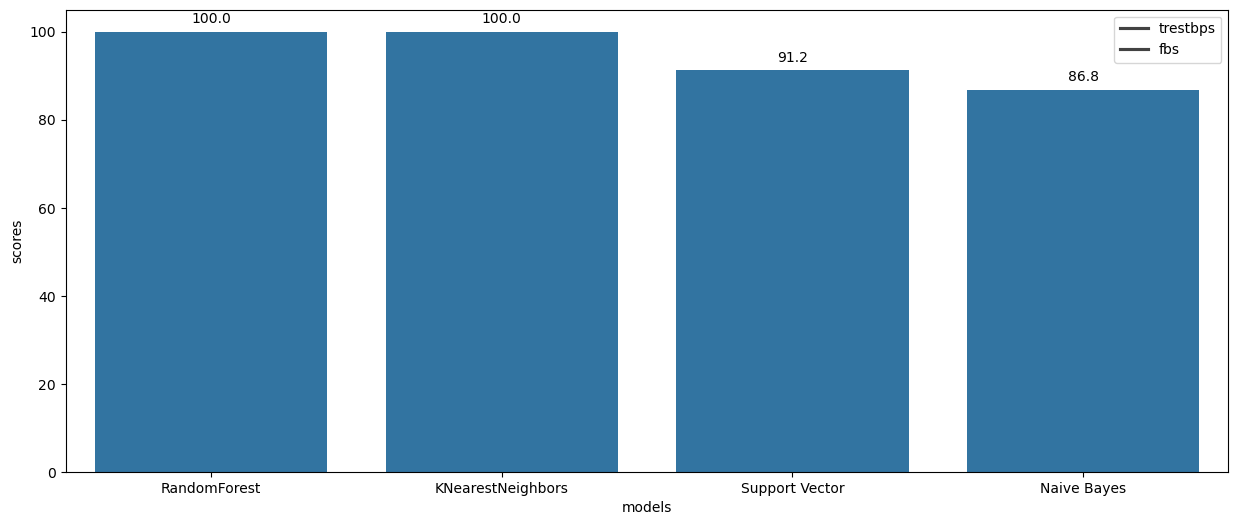

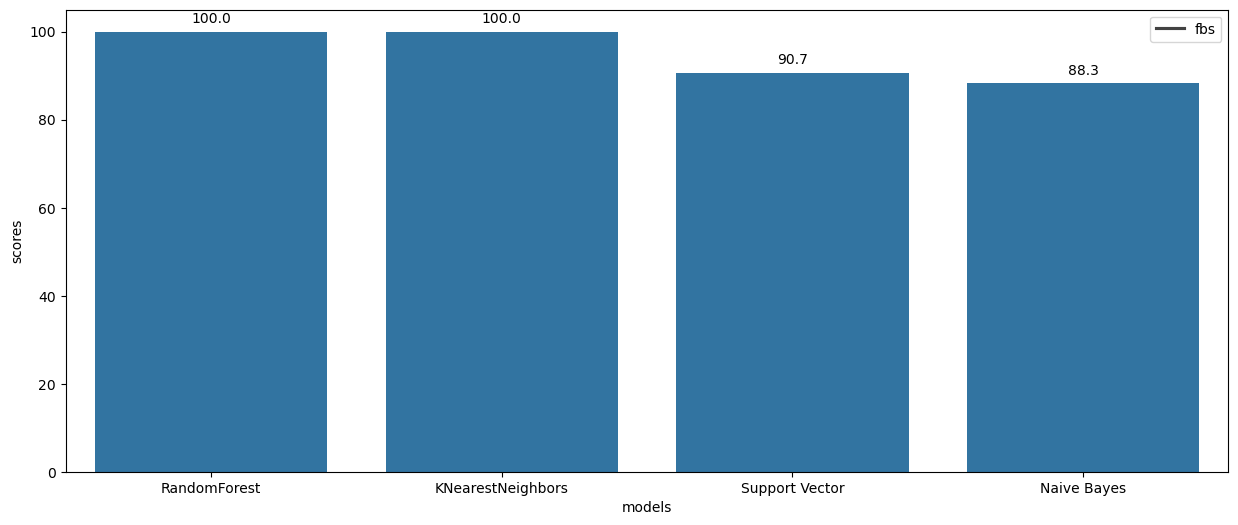

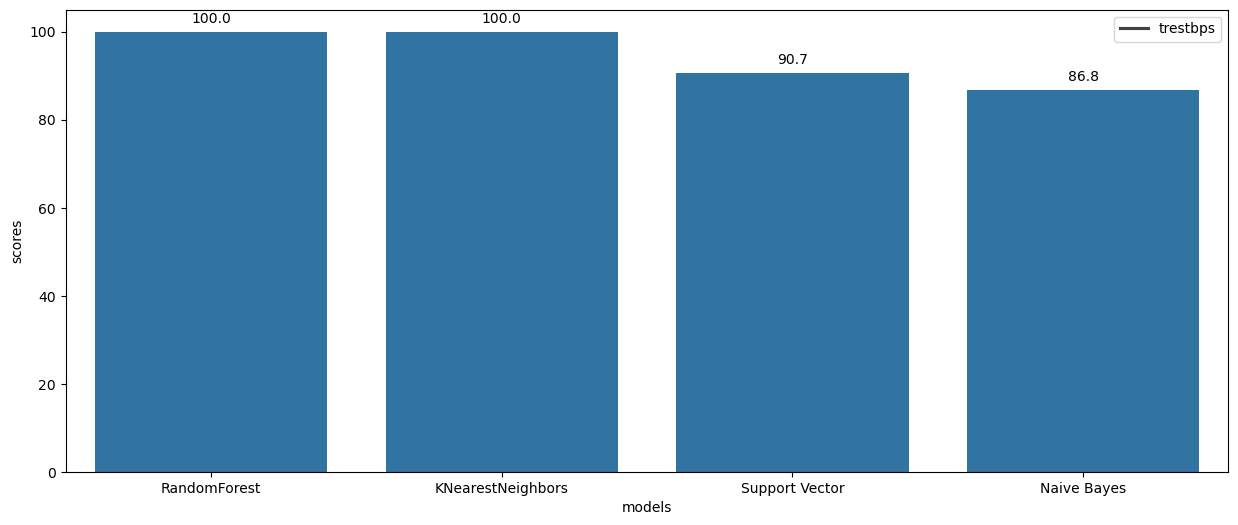

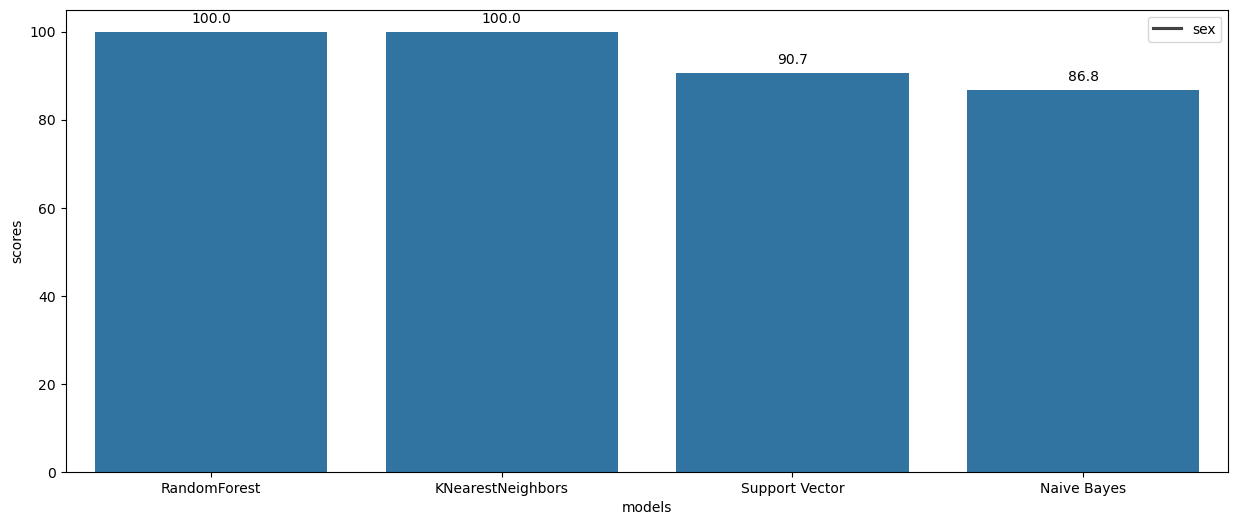

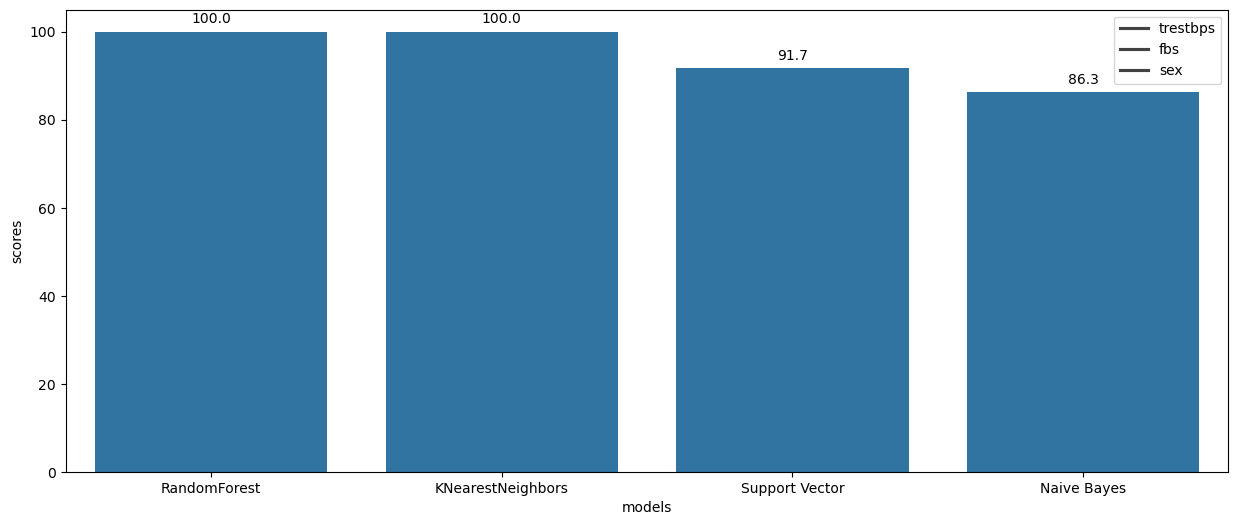

scores were :  [94.51219512 94.75609756 94.3902439  94.3902439  94.51219512] 
 

the higher score was for  94.75609756097562  by eliminating  fbs


In [54]:
balanced_sus = ['trestbps', 'fbs']
balanced_sus1 = ['fbs']
balanced_sus2 = ['trestbps']
imbalanced_sus = ['sex']
all_sus = balanced_sus + imbalanced_sus
test_features = [balanced_sus, balanced_sus1, balanced_sus2, imbalanced_sus, all_sus]
test_scores = []
for fts in test_features:
    test_data = data.copy()
    test_data.drop(columns = fts, inplace = True)
    for col in fts :
        X_train_scaled_h, X_test_scaled_h = prepare_data(test_data)
    #print('\nUsing', fts)
    test_scores.append(np.mean(evaluation(X_train_scaled_h, X_test_scaled_h, msg = fts)))
test_scores_a = np.array(test_scores)
print("scores were : ", test_scores_a, "\n \n")
print("the higher score was for ", np.max(test_scores), " by eliminating ", 
      test_features[np.argmax(test_scores_a)][0])

data = dt.drop(columns = [test_features[np.argmax(test_scores_a)][0]])

In [56]:
from sklearn.metrics import recall_score

[100.0, 100.0, 90.65420560747664, 89.7196261682243]


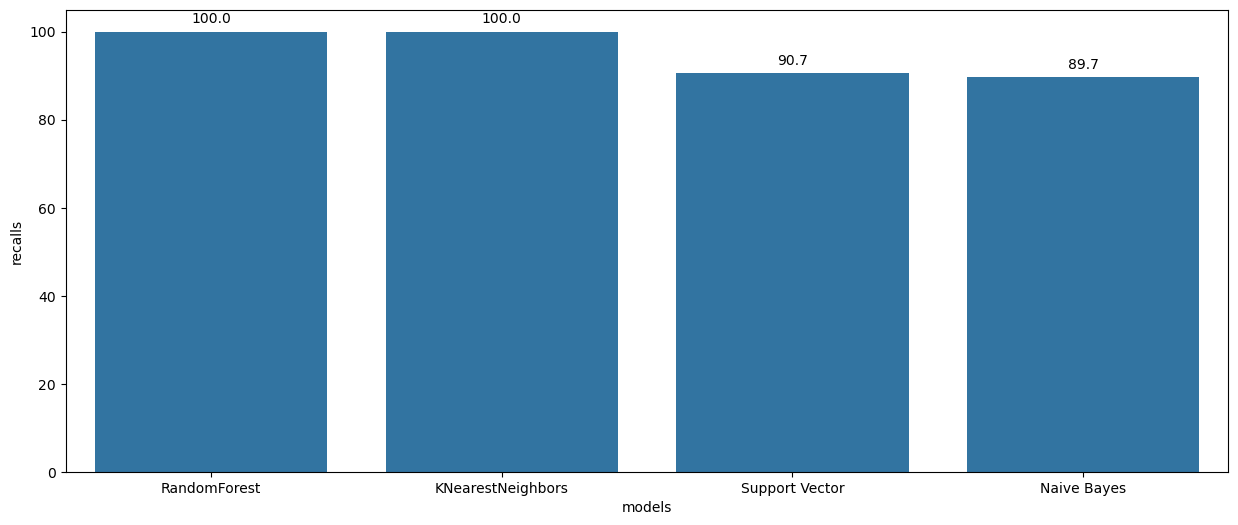

In [58]:
def recall_evaluation():
    models = {'RandomForest' : RF,
          'KNearestNeighbors': GKNN,
          'Support Vector' : SVM,
          'Naive Bayes' : NB}
    recalls = []
    dfmd = pd.DataFrame(list(models.items()),columns = ['models','params'])
    labels = models.keys()
    scores = []
    for mdl in models.values(): 
        mdl.fit(X_train_scaled, y_train)
        y_pred = mdl.predict(X_test_scaled)
        recalls.append(100 * recall_score(y_test, y_pred, average='binary'))
    dfmd['recalls'] = recalls
    print(recalls)
    splot = sns.barplot(data = dfmd, y = 'recalls', x = 'models')
    for p in splot.patches:
        splot.annotate(format(p.get_height(), '.1f'), 
                       (p.get_x() + p.get_width() / 2., p.get_height()), 
                       ha = 'center', va = 'center', 
                       xytext = (0, 9), 
                       textcoords = 'offset points')
    plt.show()
    
recall_evaluation()

In [60]:
print("On default scoring")
print('  Train score  : ', SVM.score(X_train_scaled, y_train))
print('  Test score   : ', SVM.score(X_test_scaled, y_test))
print('\n\n')


print("On recall scoring")
y_pred = SVM.predict(X_test_scaled)
print('  Train score  :', 100 * recall_score(y_test, y_pred, average='binary'))
y_pred = SVM.predict(X_train_scaled)
print('  Test score   :', 100 * recall_score(y_train, y_pred, average='binary'))

On default scoring
  Train score  :  0.8963414634146342
  Test score   :  0.9024390243902439



On recall scoring
  Train score  : 90.65420560747664
  Test score   : 88.54415274463007
